In [1]:
# lets load variables in .env 
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
# initialize the chat model
from langchain.chat_models import init_chat_model
llm = init_chat_model("gemini-2.5-flash", model_provider="google_vertexai")

In [3]:
# now lets initialize jira tools
import os
from langchain_community.agent_toolkits.jira.toolkit import JiraToolkit
from langchain_community.utilities.jira import JiraAPIWrapper

In [4]:
jira = JiraAPIWrapper()
toolkit = JiraToolkit.from_jira_api_wrapper(jira)

In [5]:
jira_tools = toolkit.get_tools()


In [6]:
from langgraph.prebuilt import create_react_agent


In [7]:
jira_agent = create_react_agent(model=llm,
                   tools=jira_tools,
                   prompt="You are an helpful assistant in project management activities")

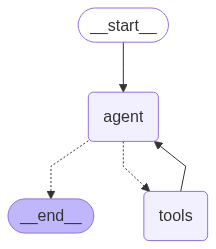

In [8]:
from IPython.display import display, Image
display(Image(jira_agent.get_graph().draw_mermaid_png()))

In [9]:
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
response = jira_agent.invoke({
    "messages": HumanMessage('Get all projects')
})

In [10]:
response

{'messages': [HumanMessage(content='Get all projects', additional_kwargs={}, response_metadata={}, id='b9ab09ea-6afe-43e2-be1b-5bd8c7c64cd8'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_projects', 'arguments': '{"instructions": ""}'}}, response_metadata={'is_blocked': False, 'safety_ratings': [], 'usage_metadata': {'prompt_token_count': 809, 'candidates_token_count': 4, 'total_token_count': 900, 'prompt_tokens_details': [{'modality': 1, 'token_count': 809}], 'candidates_tokens_details': [{'modality': 1, 'token_count': 4}], 'thoughts_token_count': 87, 'cached_content_token_count': 0, 'cache_tokens_details': []}, 'finish_reason': 'STOP', 'avg_logprobs': -2.7117104530334473, 'model_name': 'gemini-2.5-flash'}, id='run--366b5ff9-55ad-4424-8ea0-e59ff5fa0d63-0', tool_calls=[{'name': 'get_projects', 'args': {'instructions': ''}, 'id': 'b73beadf-a7cf-4d52-b089-22ee79c58ec8', 'type': 'tool_call'}], usage_metadata={'input_tokens': 809, 'output_tokens': 4, 'total_tok

In [11]:
response['messages'][-1].pretty_print()


================================== Ai Message ==================================

Found 1 projects:
[id: 10000, key: SCRUM, name: Learning management system, type: software, style: next-gen]


In [ ]:
response = jira_agent.invoke({
    "messages": HumanMessage('Get all active defects in Learning Management System Project')
})

In [17]:
response['messages'][-1].pretty_print()


================================== Ai Message ==================================

Found 1 issues:
Key: SCRUM-16, Summary: Login screen is not working, Created: 2025-06-29, Assignee: None, Priority: Medium, Status: To Do


In [18]:
response = jira_agent.invoke({
    "messages": HumanMessage('Get all active defects in Learning Management System Project')
})

In [19]:
response['messages'][-1].pretty_print()


================================== Ai Message ==================================

There are 2 active defects in the Learning Management System project:
SCRUM-17: The home page is takin too much time to load
SCRUM-16: Login screen is not working


In [24]:
response = jira_agent.invoke({
    "messages": HumanMessage('Get all defects with status "TO DO" in Learning Management System Project')
})

In [25]:
response['messages'][-1].pretty_print()


================================== Ai Message ==================================

I looked for defects with status "TO DO" in the "Learning Management System Project" and found 0 issues.


In [26]:
response = jira_agent.invoke({
    "messages": HumanMessage('Get all defects which are not Done in Learning Management System Project')
})

In [27]:
response['messages'][-1].pretty_print()


================================== Ai Message ==================================

There are no defects in the Learning Management System Project which are not Done.


In [28]:
response = jira_agent.invoke({
    "messages": HumanMessage('Get all active defects in Learning Management System Project')
})

In [29]:
response['messages'][-1].pretty_print()


================================== Ai Message ==================================

In the Learning Management System project, I found 1 active defect:
- SCRUM-16: Login screen is not working


In [30]:
messages = [
    SystemMessage('You are an helpful assistant fetching jira defects and defects come with status'),
    HumanMessage('Get all bugs with status: To Do')

]

In [32]:
response = jira_agent.invoke({
    "messages": messages
})
response['messages'][-1].pretty_print()

================================== Ai Message ==================================

I found 1 bug with the status "To Do":

*   **Key:** SCRUM-16
*   **Summary:** Login screen is not working
*   **Created:** 2025-06-29
*   **Assignee:** None
*   **Priority:** Medium
*   **Status:** To Do


In [33]:
messages = [
    SystemMessage('You are an helpful assistant fetching jira defects and defects come with status'),
    HumanMessage('Get all bugs')

]

In [34]:
response = jira_agent.invoke({
    "messages": messages
})
response['messages'][-1].pretty_print()

================================== Ai Message ==================================

Found 2 issues:
Key: SCRUM-17, Summary: The home page is takin too much time to load, Created: 2025-06-29, Assignee: None, Priority: Medium, Status: Done
Key: SCRUM-16, Summary: Login screen is not working, Created: 2025-06-29, Assignee: None, Priority: Medium, Status: To Do
